### MNA Workshop
##### Week Day 3 - GLM
##### This scripte was done with help of NMA course, which provided most of the code for participants to pracyice computational neuroscience tools. 
##### The Python library sklearn is used here.
##### Tutorial 1: receptive field estimation, spike-triggered averaging. Tutorial 2: ‘Poisson GLMs’. Tutorial 3: logistic regression and show how it can be used for decoding, how GLMs can be used to model the dynamics of single neurons and neural population dynamics, and how they can be used to model the responses of neurons in decision-making tasks and to decode behavioural choices from neurons.


In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.io import loadmat

In [3]:
# @title Figure settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

# @title Plotting Functions

def plot_stim_and_spikes(stim, spikes, dt, nt=120):
  """Show time series of stim intensity and spike counts.

  Args:
    stim (1D array): vector of stimulus intensities
    spikes (1D array): vector of spike counts
    dt (number): duration of each time step
    nt (number): number of time steps to plot

  """
  timepoints = np.arange(nt)
  time = timepoints * dt

  f, (ax_stim, ax_spikes) = plt.subplots(
    nrows=2, sharex=True, figsize=(8, 5),
  )
  ax_stim.plot(time, stim[timepoints])
  ax_stim.set_ylabel('Stimulus intensity')

  ax_spikes.plot(time, spikes[timepoints])
  ax_spikes.set_xlabel('Time (s)')
  ax_spikes.set_ylabel('Number of spikes')

  f.tight_layout()
  plt.show()


def plot_glm_matrices(X, y, nt=50):
  """Show X and Y as heatmaps.

  Args:
    X (2D array): Design matrix.
    y (1D or 2D array): Target vector.

  """
  from matplotlib.colors import BoundaryNorm
  from mpl_toolkits.axes_grid1 import make_axes_locatable
  Y = np.c_[y]  # Ensure Y is 2D and skinny

  f, (ax_x, ax_y) = plt.subplots(
    ncols=2,
    figsize=(6, 8),
    sharey=True,
    gridspec_kw=dict(width_ratios=(5, 1)),
  )
  norm = BoundaryNorm([-1, -.2, .2, 1], 256)
  imx = ax_x.pcolormesh(X[:nt], cmap="coolwarm", norm=norm)

  ax_x.set(
    title="X\n(lagged stimulus)",
    xlabel="Time lag (time bins)",
    xticks=[4, 14, 24],
    xticklabels=['-20', '-10', '0'],
    ylabel="Time point (time bins)",
  )
  plt.setp(ax_x.spines.values(), visible=True)

  divx = make_axes_locatable(ax_x)
  caxx = divx.append_axes("right", size="5%", pad=0.1)
  cbarx = f.colorbar(imx, cax=caxx)
  cbarx.set_ticks([-.6, 0, .6])
  cbarx.set_ticklabels(np.sort(np.unique(X)))

  norm = BoundaryNorm(np.arange(y.max() + 1), 256)
  imy = ax_y.pcolormesh(Y[:nt], cmap="magma", norm=norm)
  ax_y.set(
    title="Y\n(spike count)",
    xticks=[]
  )
  ax_y.invert_yaxis()
  plt.setp(ax_y.spines.values(), visible=True)

  divy = make_axes_locatable(ax_y)
  caxy = divy.append_axes("right", size="30%", pad=0.1)
  cbary = f.colorbar(imy, cax=caxy)
  cbary.set_ticks(np.arange(y.max()) + .5)
  cbary.set_ticklabels(np.arange(y.max()))
  plt.show()


def plot_spike_filter(theta, dt, show=True, **kws):
  """Plot estimated weights based on time lag model.

  Args:
    theta (1D array): Filter weights, not including DC term.
    dt (number): Duration of each time bin.
    kws: Pass additional keyword arguments to plot()
    show (boolean): To plt.show or not the plot.
  """
  d = len(theta)
  t = np.arange(-d + 1, 1) * dt

  ax = plt.gca()
  ax.plot(t, theta, marker="o", **kws)
  ax.axhline(0, color=".2", linestyle="--", zorder=1)
  ax.set(
    xlabel="Time before spike (s)",
    ylabel="Filter weight",
  )
  if show:
    plt.show()


def plot_spikes_with_prediction(spikes, predicted_spikes, dt,
                                nt=50, t0=120, **kws):
  """Plot actual and predicted spike counts.

  Args:
    spikes (1D array): Vector of actual spike counts
    predicted_spikes (1D array): Vector of predicted spike counts
    dt (number): Duration of each time bin.
    nt (number): Number of time bins to plot
    t0 (number): Index of first time bin to plot.
    show (boolean): To plt.show or not the plot.
    kws: Pass additional keyword arguments to plot()

  """
  t = np.arange(t0, t0 + nt) * dt

  f, ax = plt.subplots()
  lines = ax.stem(t, spikes[:nt])
  plt.setp(lines, color=".5")
  lines[-1].set_zorder(1)
  kws.setdefault("linewidth", 3)
  yhat, = ax.plot(t, predicted_spikes[:nt], **kws)
  ax.set(
      xlabel="Time (s)",
      ylabel="Spikes",
  )
  ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
  ax.legend([lines[0], yhat], ["Spikes", "Predicted"])
  plt.show()

  # @title Data retrieval and loading
import os
import hashlib
import requests

fname = "RGCdata.mat"
url = "https://osf.io/mzujs/download"
expected_md5 = "1b2977453020bce5319f2608c94d38d0"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    elif hashlib.md5(r.content).hexdigest() != expected_md5:
      print("!!! Data download appears corrupted !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

### Tutorial 1: GLMs for Encoding
#### Section 1: Linear-Gaussian GLM
##### data from an experiment that presented a screen which randomly alternated between two luminance values and recorded responses from retinal ganglion cell (RGC), a type of neuron in the retina in the back of the eye. This kind of visual stimulus is called a “full-field flicker”, and it was presented at ~120Hz (ie. the stimulus presented on the screen was refreshed about every 8ms). These same time bins were used to count the number of spikes emitted by each neuron.

##### The file RGCdata.mat contains three variables:
##### Stim, the stimulus intensity at each time point. It is an array with shape T*1, where T = 144051 
##### SpCounts, the binned spike counts for 2 ON cells, and 2 OFF cells. It is a 144051 *4 array, and each column has counts for a different cell.
##### dtStim, the size of a single time bin (in seconds), which is needed for computing model output in units of spikes / s. The stimulus frame rate is given by 1 / dtStim.

In [17]:
# load retina ganglion cell activity data and 
# process data saved in MATLAB to more Pythonic representations

data = loadmat('RGCdata.mat')    # loadmat - function in scipy.io
dt_stim = data['dtStim'].item()  # .item extracts a scalar value

# Extract the stimulus intensity
stim = data['Stim'].squeeze()  # .squeeze removes dimensions with 1 element

# Extract the spike counts for one cell
cellnum = 2 # we have only 4 cells: 2 ON and 2 OFF cells
spikes = data['SpCounts'][:, cellnum] #  binned spike counts for 2 ON and 2 OFF cells

keep_timepoints = 20000 # to not use all timepoints in the dataset, for speed
stim = stim[:keep_timepoints]
spikes = spikes[:keep_timepoints]

In [20]:
print(len(stim))

20000


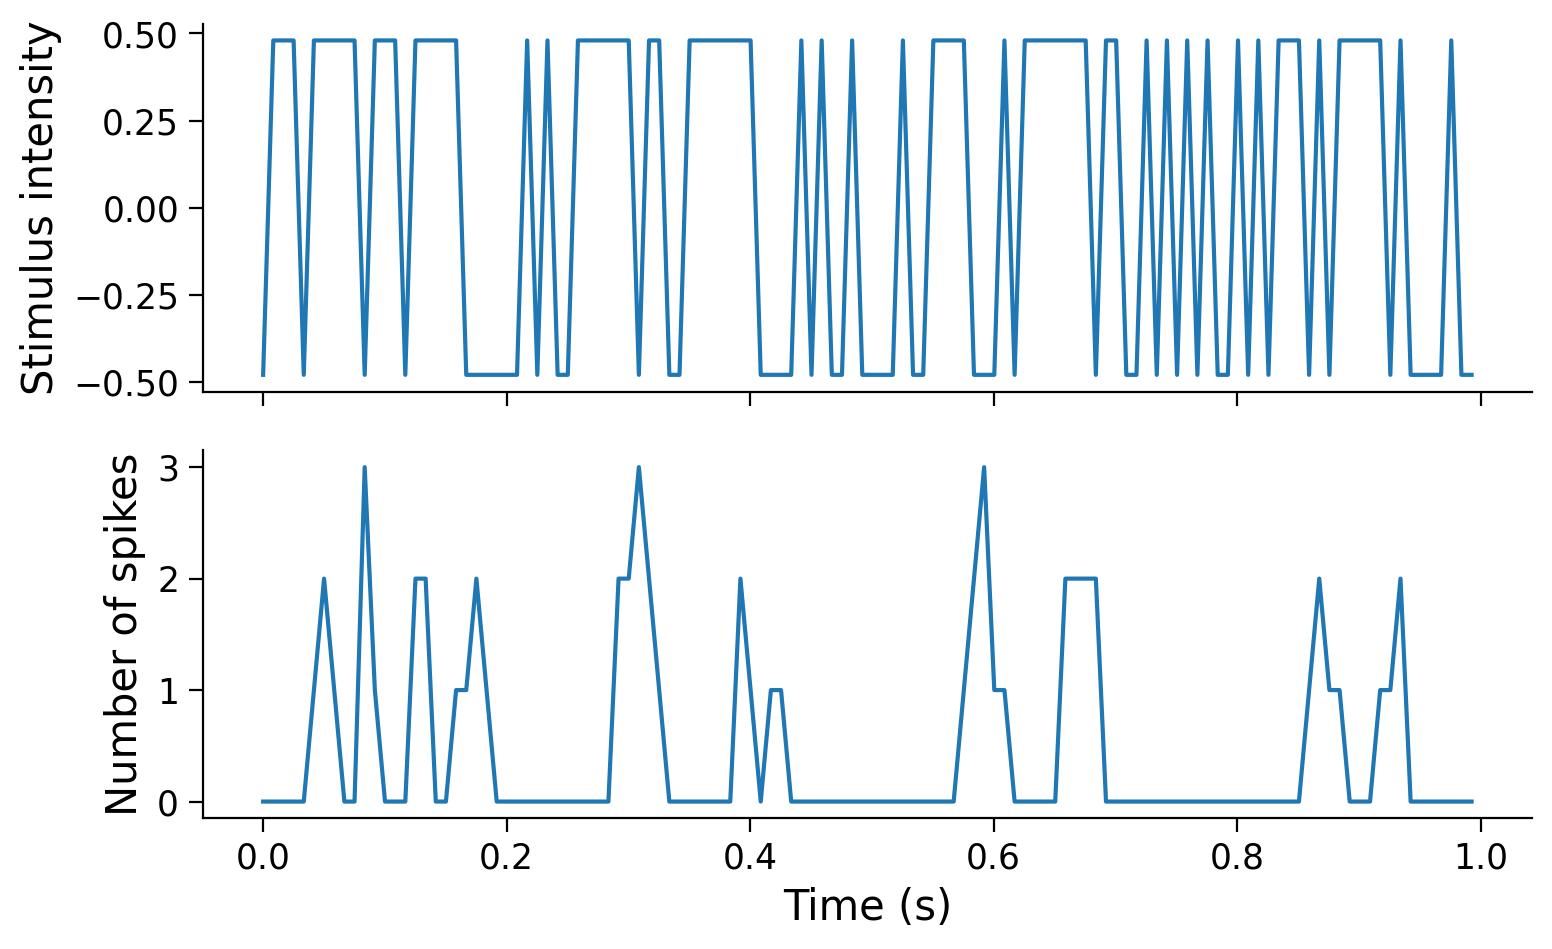

In [18]:
# changes in stimulus intensities and spike counts over time
plot_stim_and_spikes(stim, spikes, dt_stim)

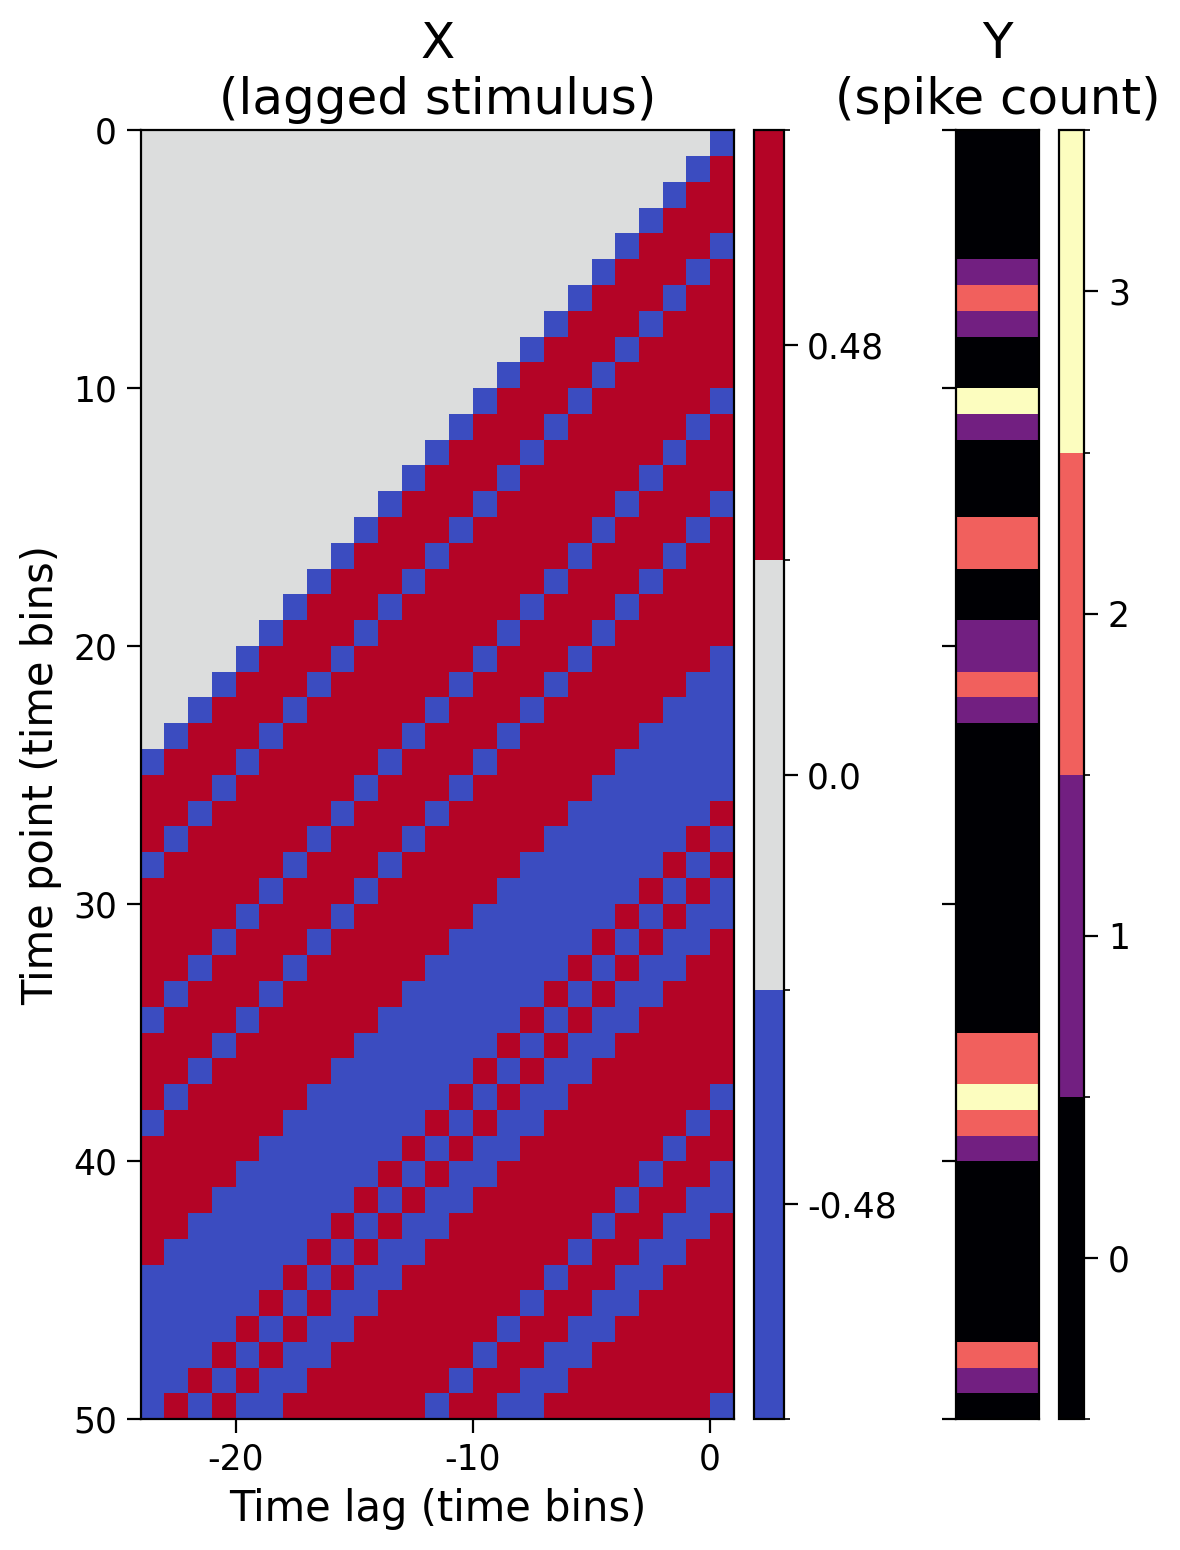

In [21]:
# goal: predict the cell’s activity from stimulus intensities preceding it
# to understand how RGCs process information over time

def make_design_matrix(stim, d=25):
  """time-lag design matrix from stimulus intensity vector.
  Args:
    stim (1D array): Stimulus intensity at each time point.
    d (number): Number of time lags to use.
  Returns
    X (2D array): GLM design matrix with shape T, d
  """

  padded_stim = np.concatenate([np.zeros(d - 1), stim]) # stimulus vector with zeros before onset (24 zero prior to the first timepoint in the dataset)

  # matrix where each row has the d frames of stimulus preceding, including timepoint t
  T = len(stim)         # Total number of timepoints - number of stimulus frames - 20000
  X = np.zeros((T, d))
  for t in range(T):
      X[t] = padded_stim[t:t + d]
  return X

# design matrix
X = make_design_matrix(stim)

plot_glm_matrices(X, spikes, nt=50) # visual

#### Section 1.2: Fit Linear-Gaussian regression model

In [ ]:
# design matrix
y = spikes
constant = np.ones_like(y)
X = np.column_stack([constant, make_design_matrix(stim)])

# MLE weights for LG model
theta = np.linalg.inv(X.T @ X) @ X.T @ y
theta_lg = theta[1:]

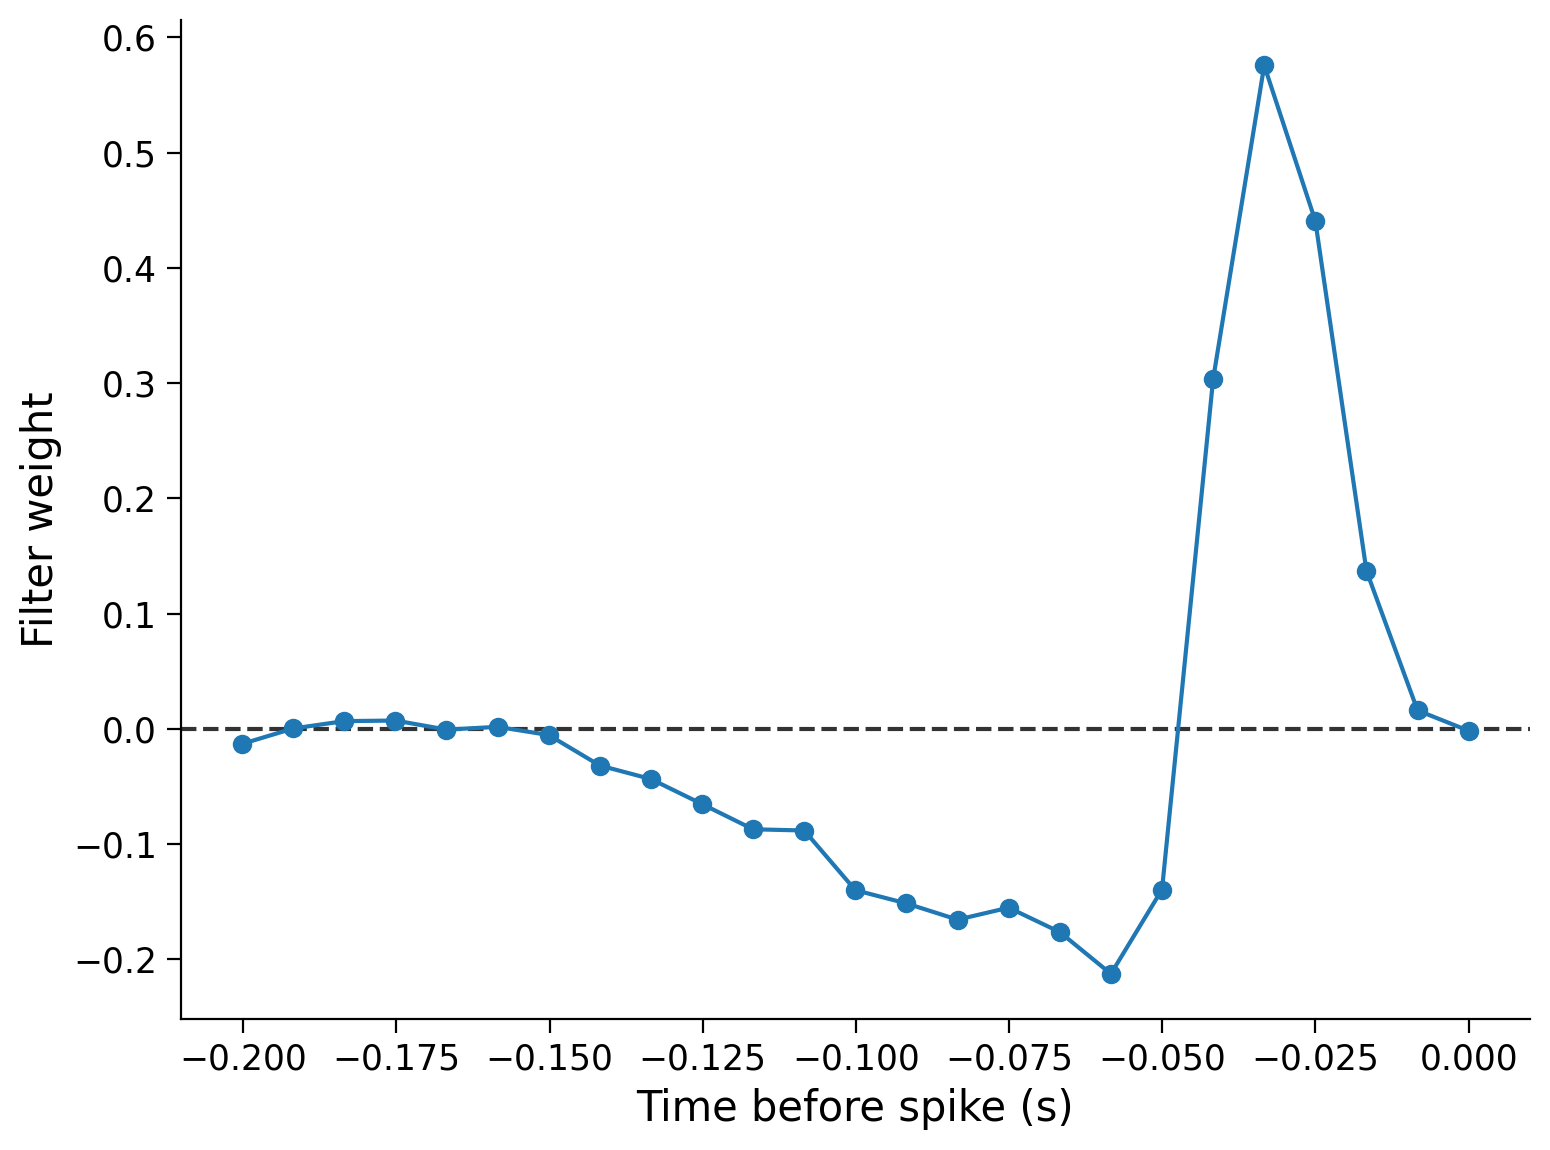

In [24]:
plot_spike_filter(theta_lg, dt_stim)

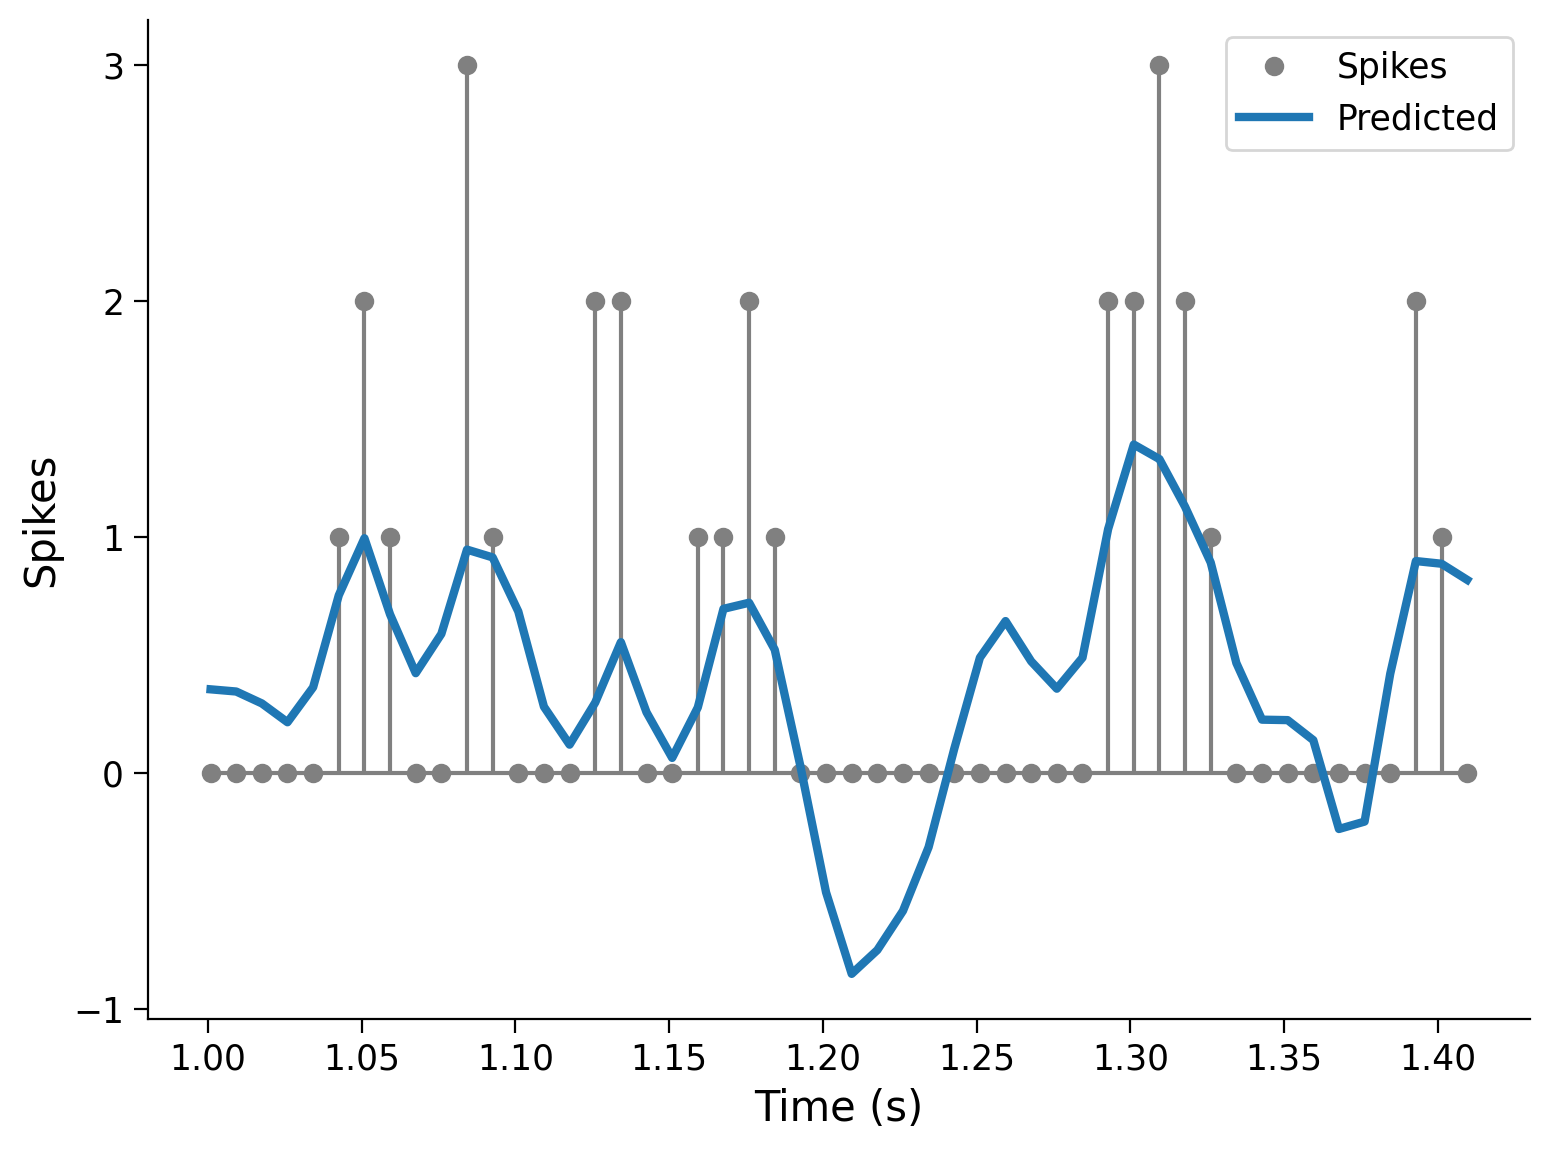

In [25]:
def predict_spike_counts_lg(stim, spikes, d=25):
  y = spikes
  constant = np.ones_like(y)
  X = np.column_stack([constant, make_design_matrix(stim)]) # design matrix
  
  theta = np.linalg.inv(X.T @ X) @ X.T @ y   # MLE weights for LG model
  yhat = X @ theta                           # predicted spike counts

  return yhat

predicted_counts = predict_spike_counts_lg(stim, spikes) # Predicting spike counts
plot_spikes_with_prediction(spikes, predicted_counts, dt_stim)

#### Note: under white noise stimulus, STA = GLM solution.Because the experiment that produced these data used a white noise stimulus, there are no such correlations. Therefore the two methods are equivalent. 

[ 1.00000000e+00 -8.12068236e-04  1.00155082e-02  8.05301001e-03
  4.12801353e-03 -9.47412942e-04 -1.69180883e-03 -8.18835472e-03
 -2.48357536e-02 -3.33624700e-02 -4.78443536e-02 -5.94839983e-02
 -5.79952065e-02 -9.19667278e-02 -9.85309460e-02 -1.06177922e-01
 -9.85986184e-02 -1.11997744e-01 -1.35480051e-01 -9.02749189e-02
  1.94828704e-01  3.70100099e-01  2.83614832e-01  8.85831101e-02
  1.29254194e-02  2.77456647e-03]


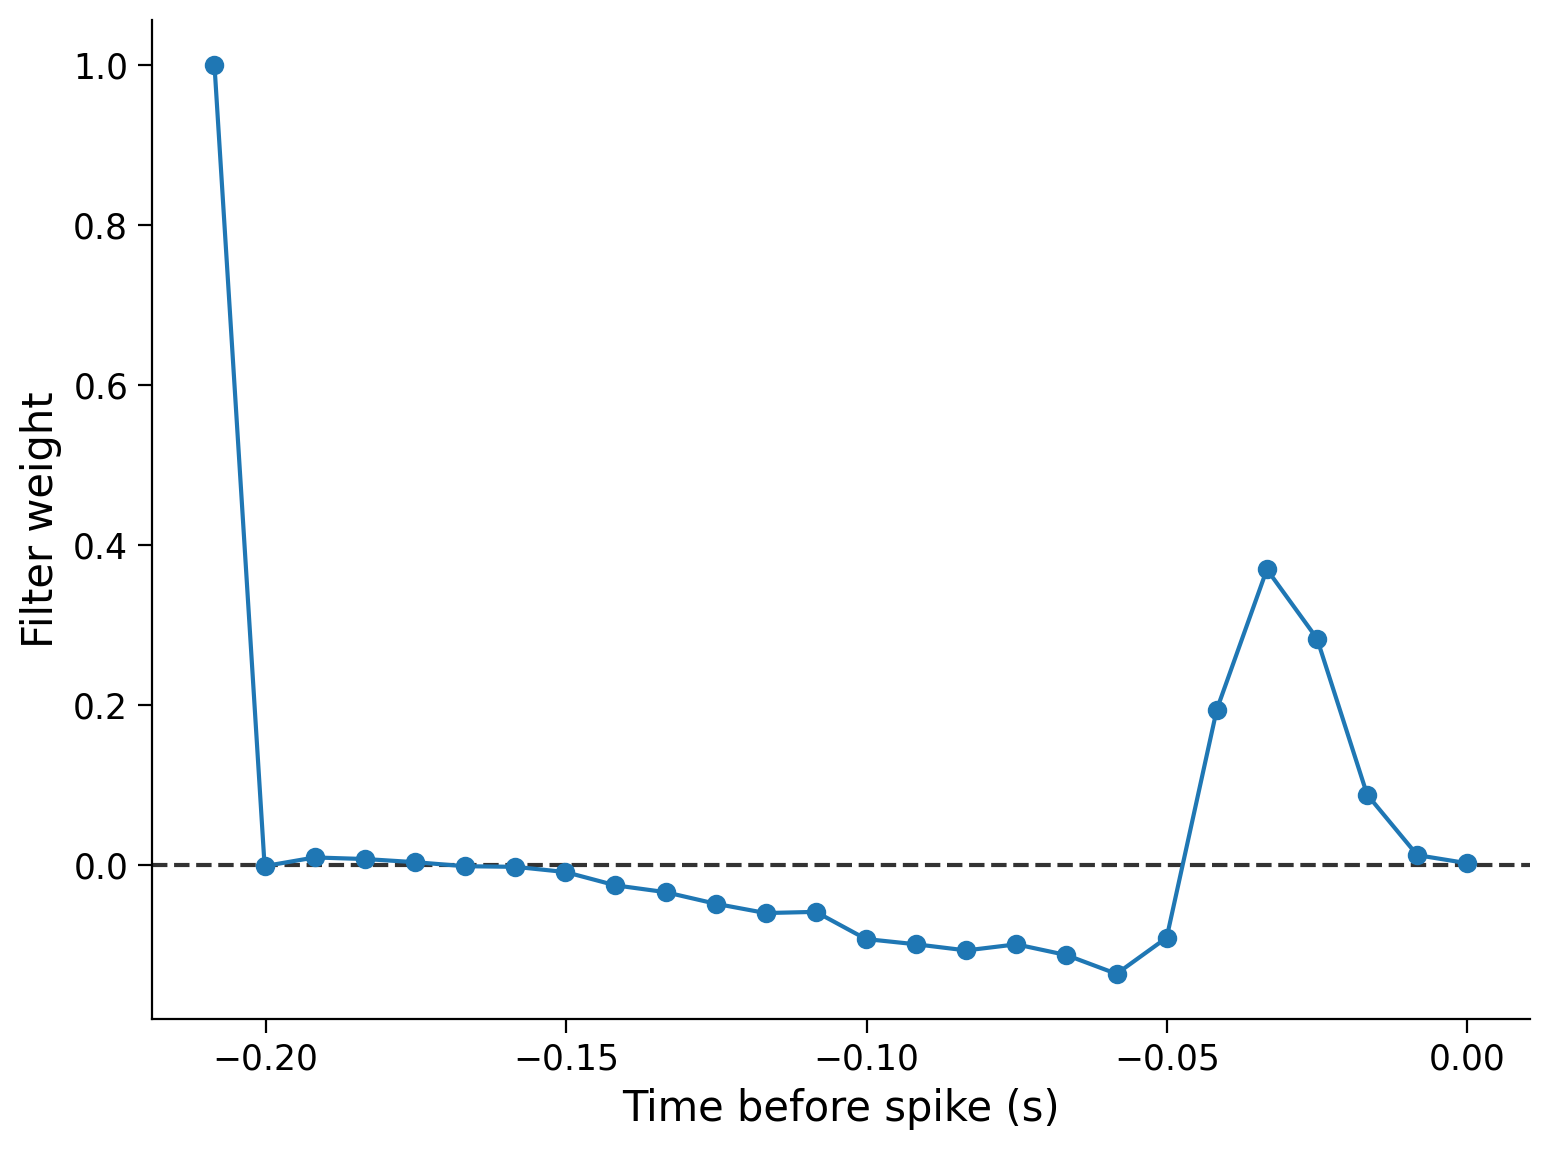

In [29]:
sta = X.T @ y / np.sum(y)
print(sta)
plot_spike_filter(sta, dt_stim)

In [30]:
# compare sta and lg gml solution 
np.cov(X.T)

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  2.30135027e-01, -1.38246912e-03,
         2.53452673e-04,  6.22111106e-04,  7.83399170e-04,
         4.60823041e-05,  1.08293415e-03,  9.21646082e-05,
        -9.44687234e-04,  7.37316866e-04,  8.29481474e-04,
        -3.24880244e-03, -2.53452673e-04,  7.14275714e-04,
        -4.37781889e-03,  7.14275714e-04,  2.53452673e-04,
        -2.99534977e-03,  3.68658433e-04,  1.65896295e-03,
         3.52529626e-03, -2.30411521e-03, -8.29481474e-04,
         1.05

### Section 2: Linear-Nonlinear-Poisson GLM

In [32]:
# with simple example 
f = np.square
res = minimize(f, x0=2)
print(f"Minimum value: {res['fun']:.4g} at x = {res['x'].item():.5e}")

Minimum value: 3.566e-16 at x = -1.88846e-08


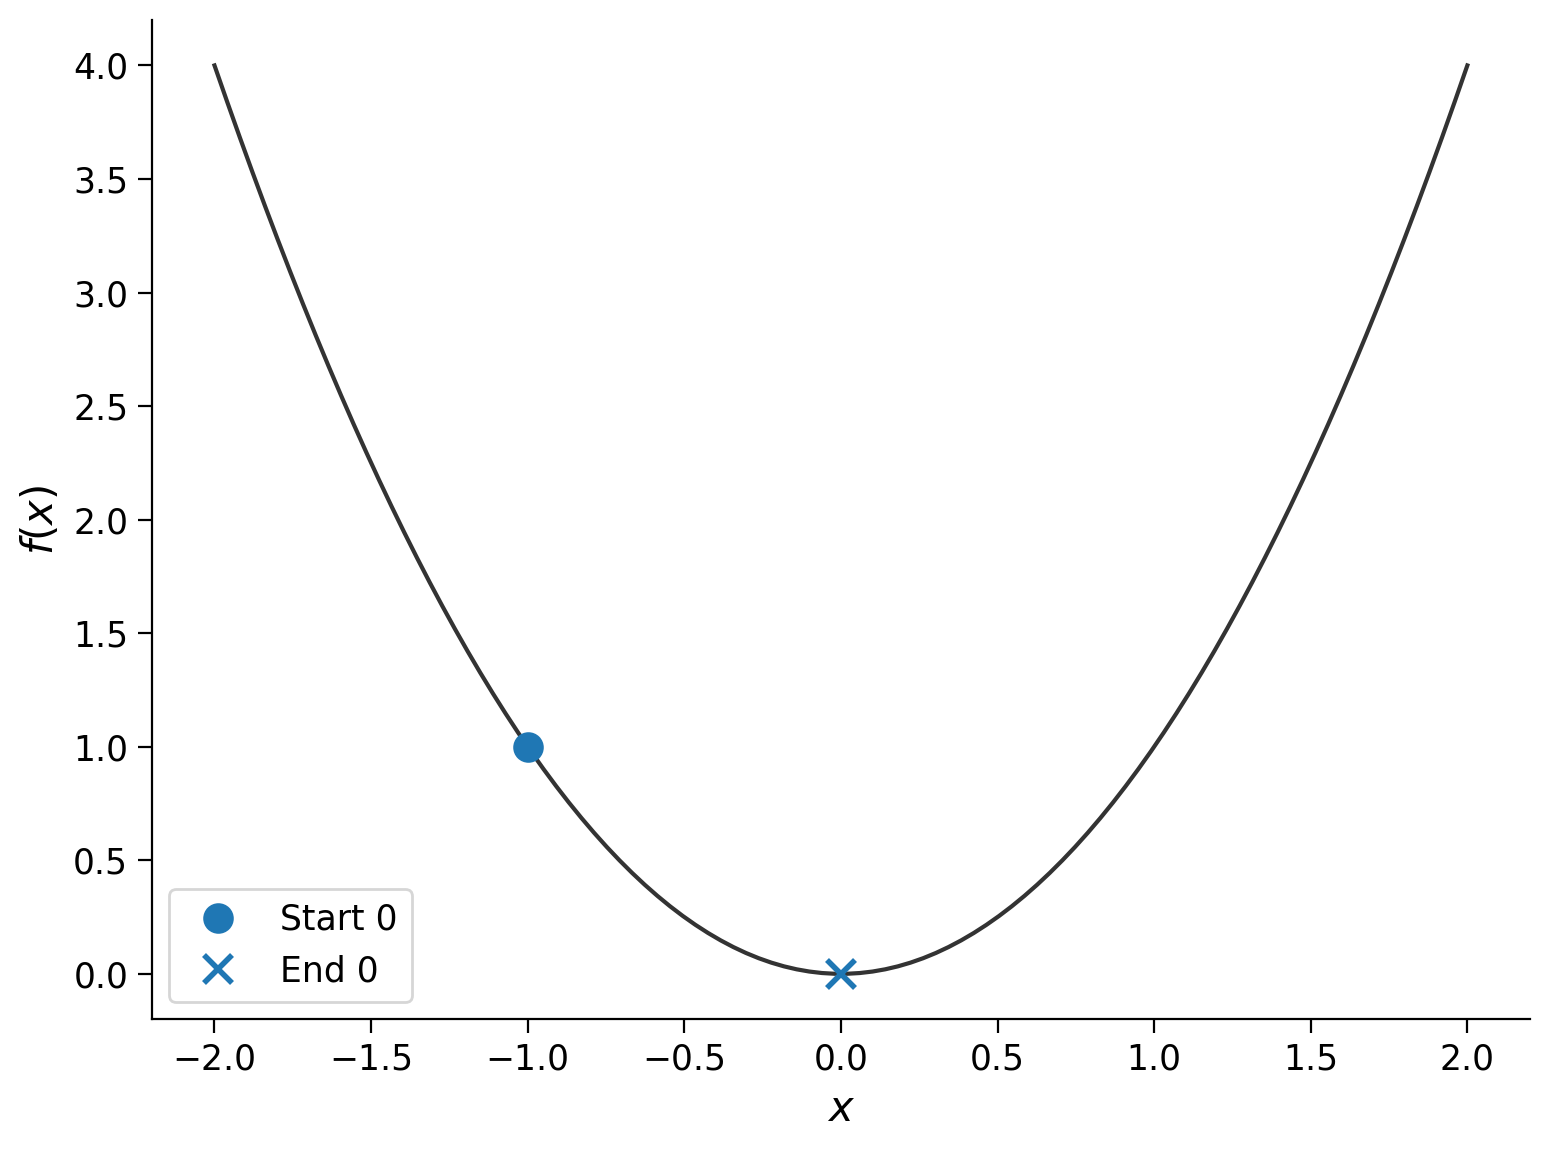

In [ ]:
start_points = -1, 1.5

xx = np.linspace(-2, 2, 100)
plt.plot(xx, f(xx), color=".2")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")

for i, x0 in enumerate(start_points):
  res = minimize(f, x0)
  plt.plot(x0, f(x0), "o", color=f"C{i}", ms=10, label=f"Start {i}")
  plt.plot(res["x"].item(), res["fun"], "x", c=f"C{i}",
           ms=10, mew=2, label=f"End {i}")
plt.legend()
plt.show()

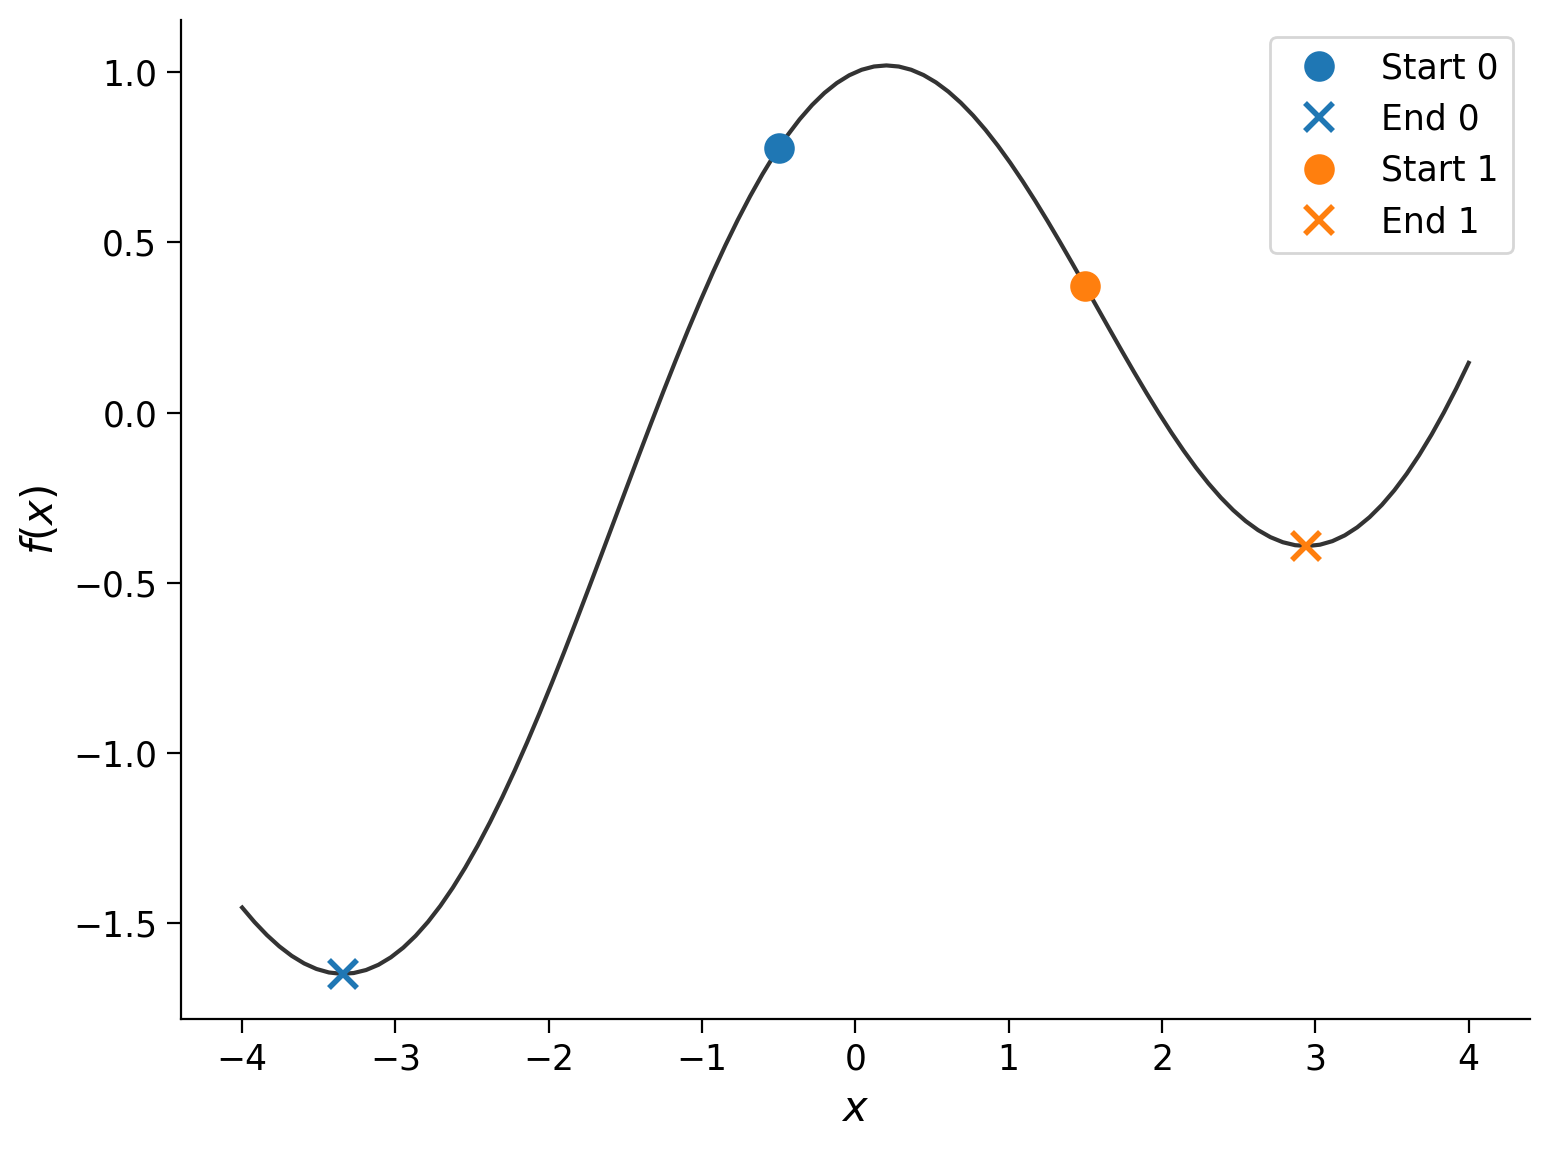

In [ ]:
# enother example 
g = lambda x: x / 5 + np.cos(x)
start_points = -.5, 1.5

xx = np.linspace(-4, 4, 100)
plt.plot(xx, g(xx), color=".2")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")

for i, x0 in enumerate(start_points):
  res = minimize(g, x0)
  plt.plot(x0, g(x0), "o", color=f"C{i}", ms=10, label=f"Start {i}")
  plt.plot(res["x"].item(), res["fun"], "x", color=f"C{i}",
           ms=10, mew=2, label=f"End {i}")
plt.legend()
plt.show()

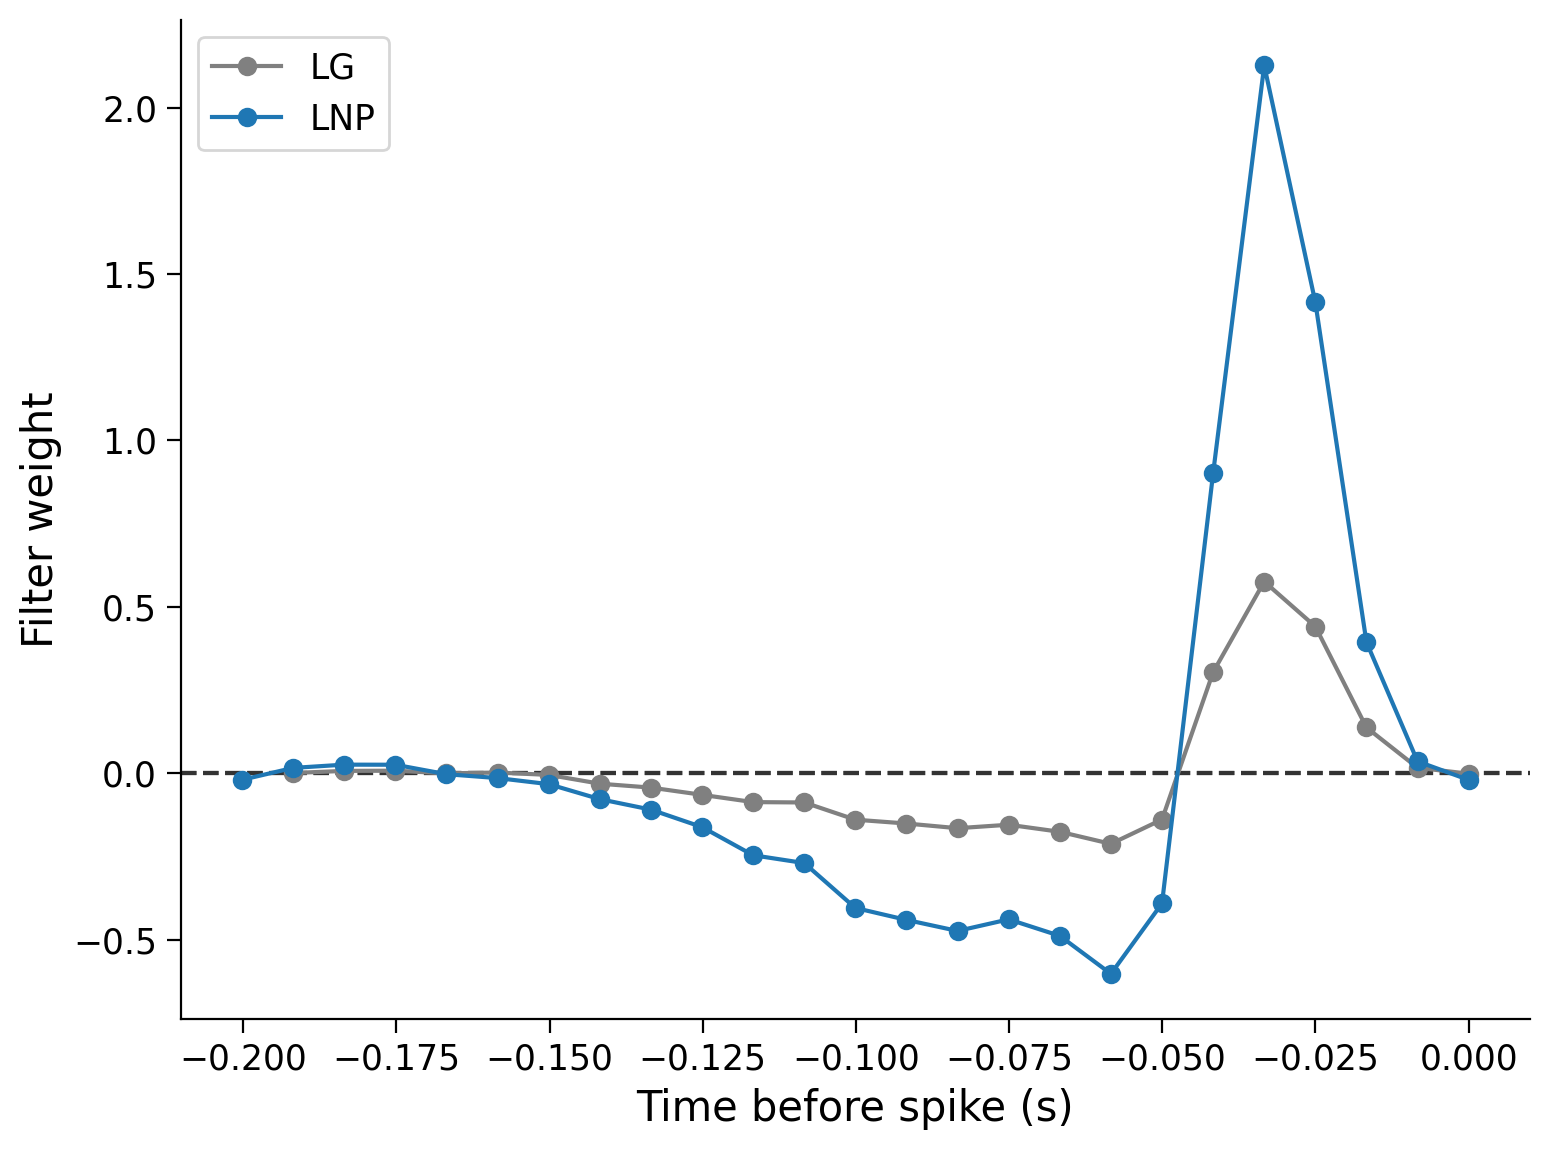

In [45]:
def neg_log_lik_lnp(theta, X, y):
  """
  Args:
    theta (1D array): Parameter vector.
    X (2D array): Full design matrix.
    y (1D array): Data values.
  Returns:
    number: Negative log likelihood.
  """

  rate = np.exp(X @ theta)
  log_lik = y @ np.log(rate) - rate.sum() # Poisson log likelihood
  return -log_lik


def fit_lnp(stim, spikes, d=25):
  """MLE parameters for the Poisson GLM
  Args:
    stim (1D array): Stimulus values at each timepoint
    spikes (1D array): Spike counts measured at each timepoint
    d (number): Number of time lags to use.
  Returns:
    1D array: MLE parameters
  """

  # design matrix
  y = spikes
  constant = np.ones_like(y)
  X = np.column_stack([constant, make_design_matrix(stim)])

  # random vector of weights to start (mean 0, sd .2)
  x0 = np.random.normal(0, .2, d + 1)

  # parameters that minimize the negative log likelihood function
  res = minimize(neg_log_lik_lnp, x0, args=(X, y))

  return res["x"]


# Fit LNP model
theta_lnp = fit_lnp(stim, spikes)

# Visualize
plot_spike_filter(theta_lg[1:], dt_stim, show=False, color=".5", label="LG")
plot_spike_filter(theta_lnp[1:], dt_stim, show=False, label="LNP")
plt.legend(loc="upper left")
plt.show()

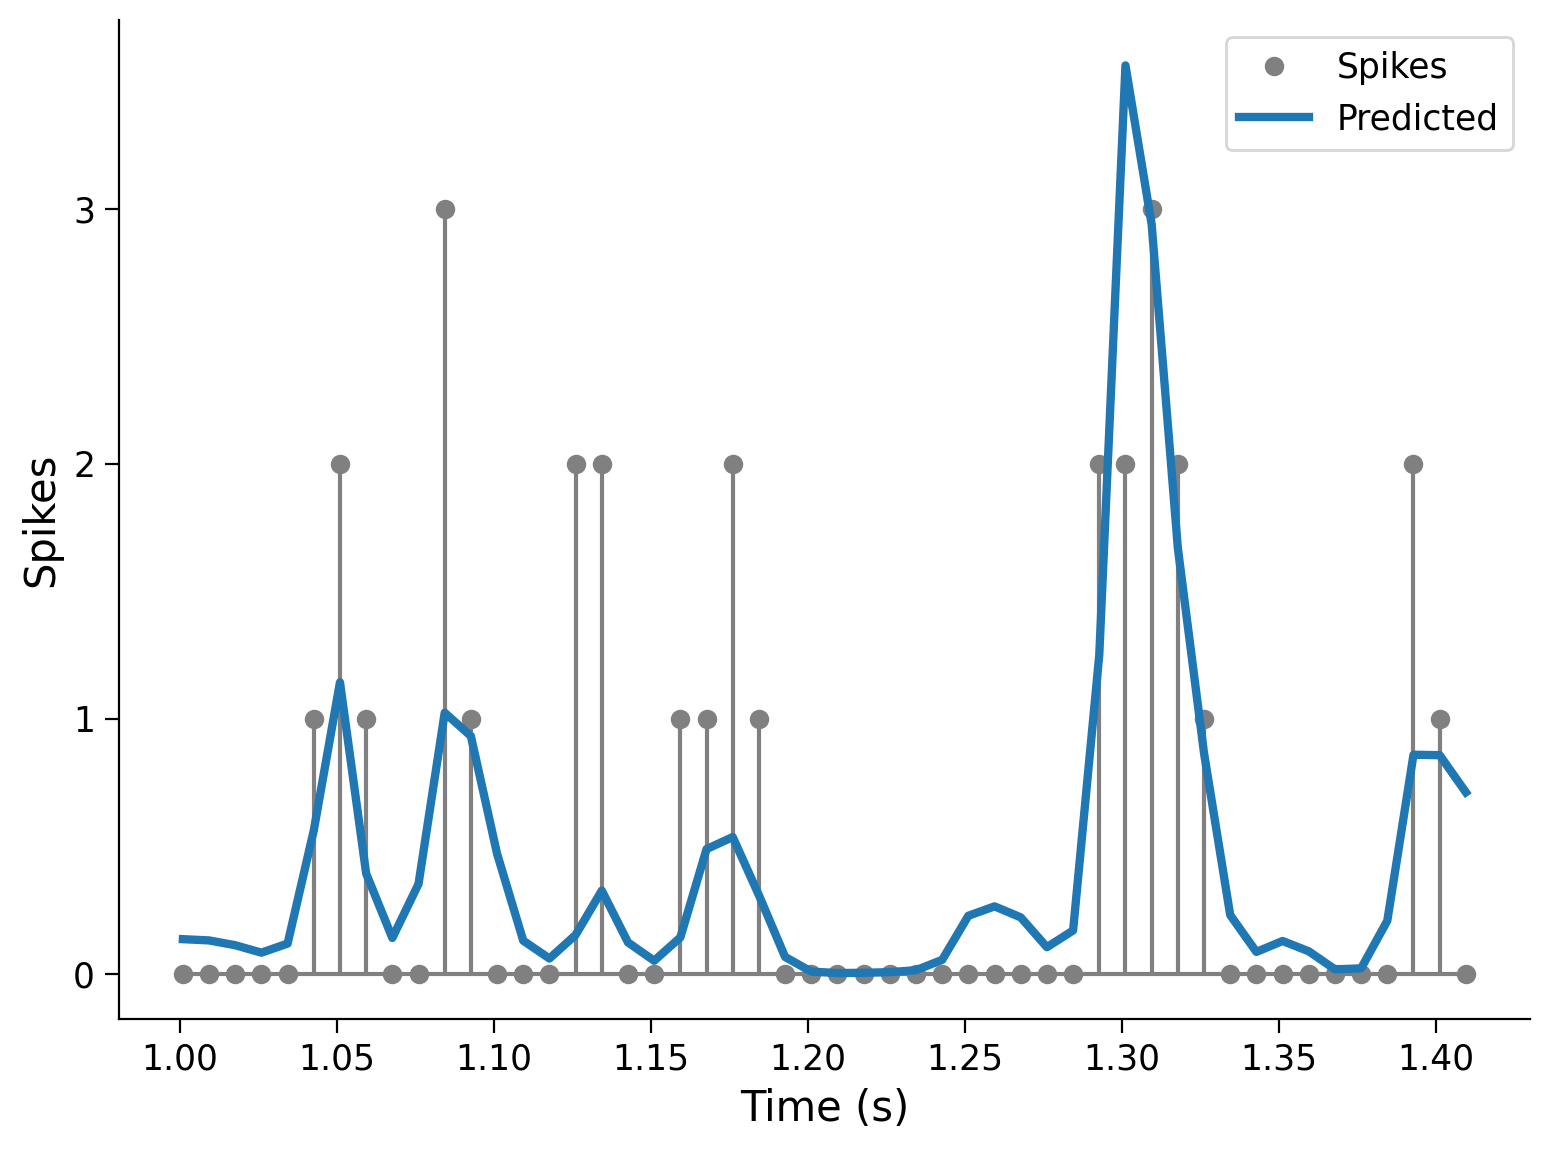

In [47]:
def predict_spike_counts_lnp(stim, spikes, theta=None, d=25):
  """vector of predicted spike counts given the stimulus.
  Args:
    stim (1D array): Stimulus values at each timepoint
    spikes (1D array): Spike counts measured at each timepoint
    theta (1D array): Filter weights; estimated if not provided.
    d (number): Number of time lags to use.
  Returns:
    yhat (1D array): Predicted spikes at each timepoint.
  """
  y = spikes
  constant = np.ones_like(spikes)
  X = np.column_stack([constant, make_design_matrix(stim)])
  if theta is None:                                      # Allow pre-cached weights, as fitting is slow
    theta = fit_lnp(X, y, d)

  yhat = np.exp(X @ theta)      
  return yhat


yhat = predict_spike_counts_lnp(stim, spikes, theta_lnp) # Predict spike counts

plot_spikes_with_prediction(spikes, yhat, dt_stim)       # Visualize

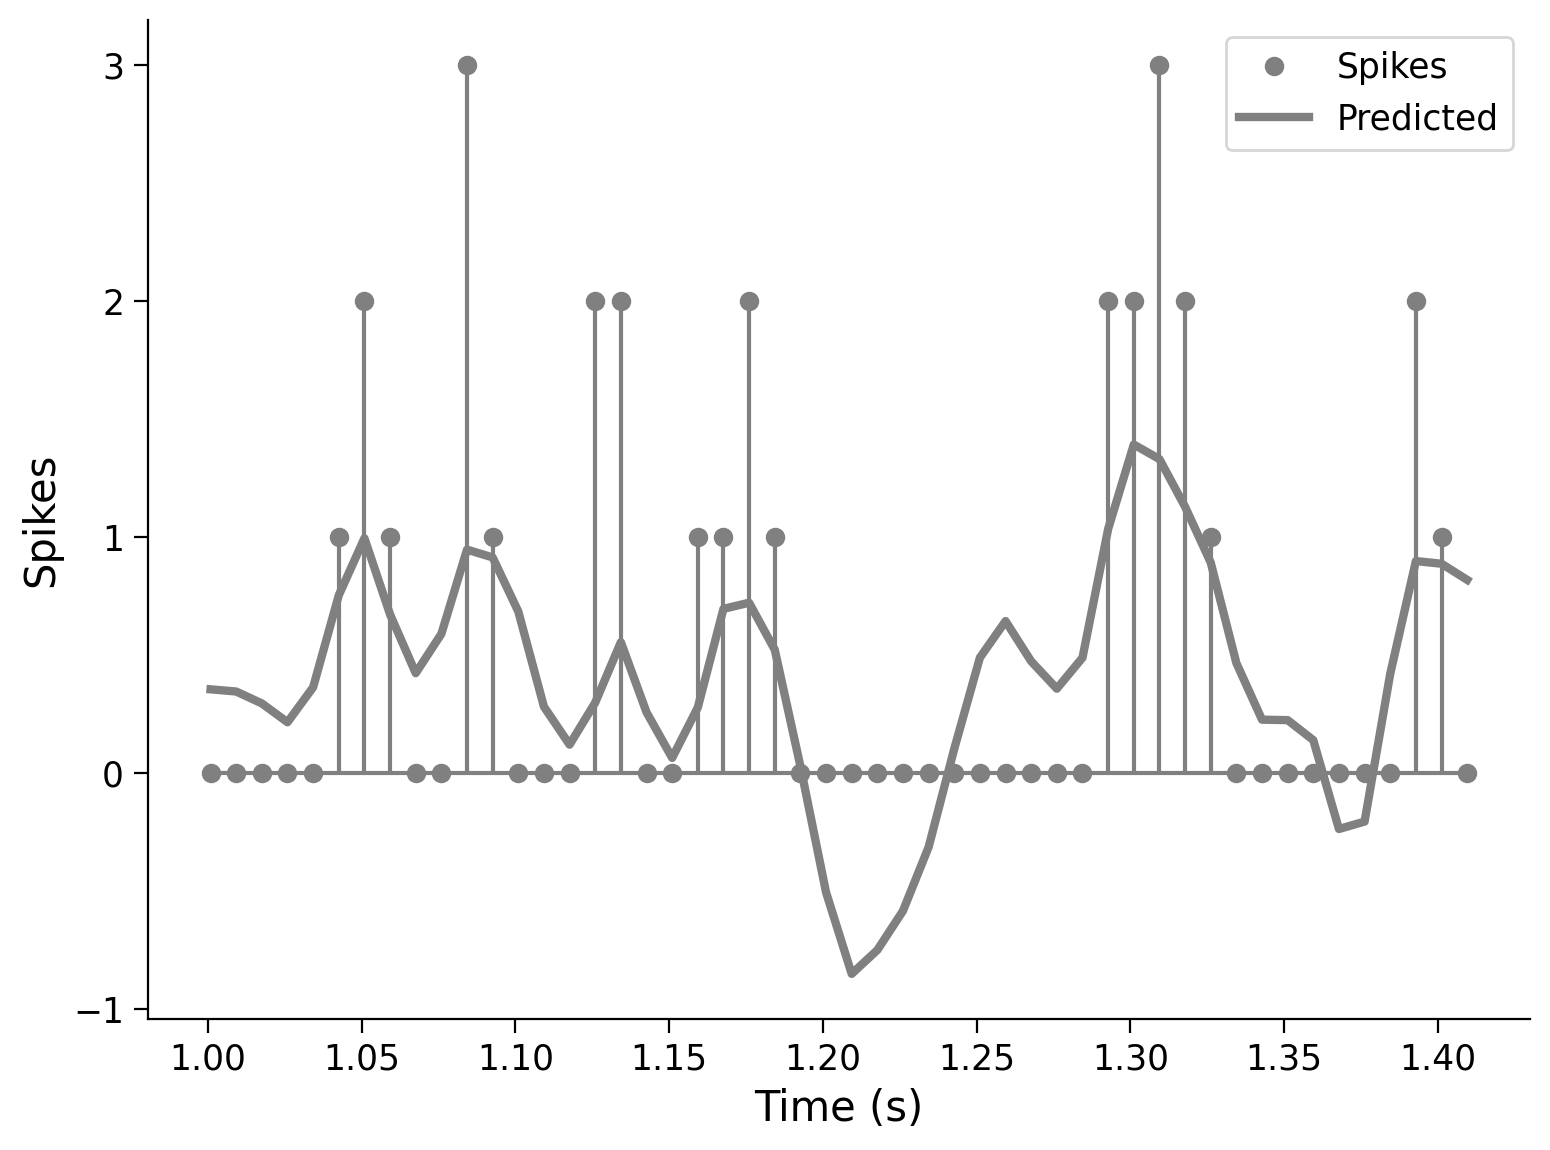

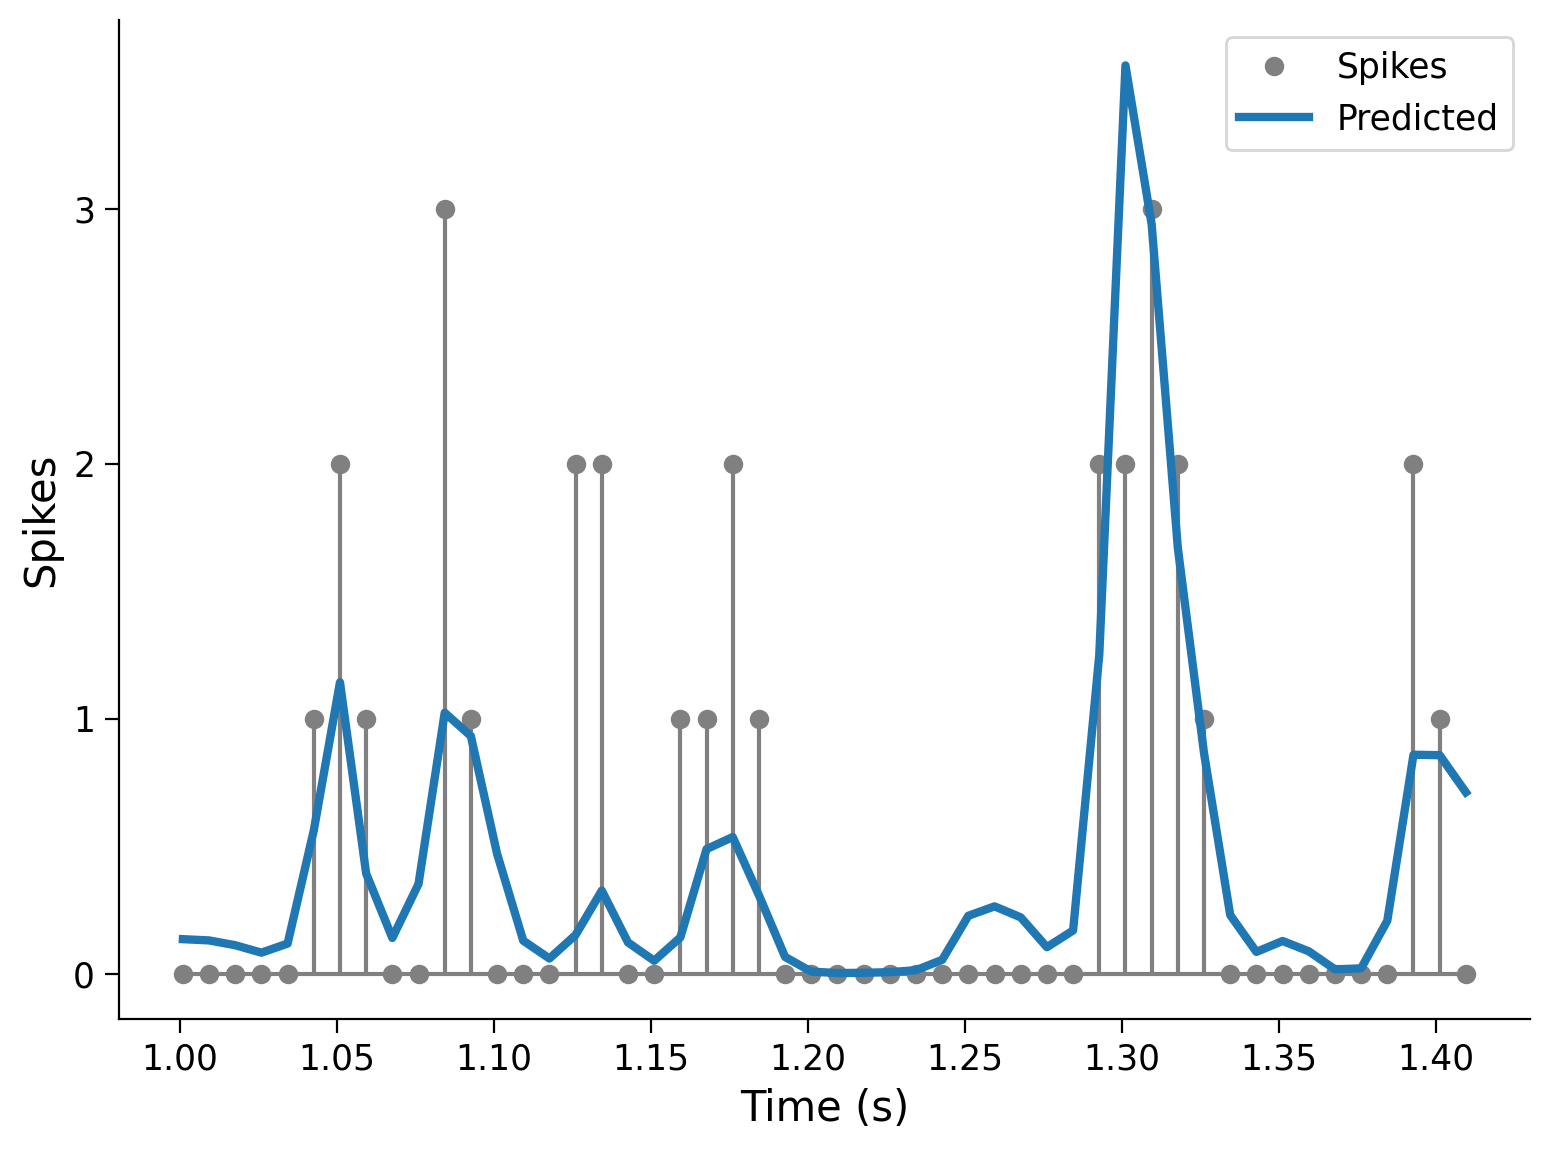

In [51]:
# put predictions together 


plot_spikes_with_prediction(spikes, predicted_counts, dt_stim, color=".5", label="LG")
plot_spikes_with_prediction(spikes, yhat, dt_stim)  
 
